In [1]:
import polars as pl
import polars.selectors as cs
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings

In [2]:
train_df = pl.read_csv("C:/CreditScoringMLE/ml_service/app/data/application_train.csv")
test_df = pl.read_csv("C:/CreditScoringMLE/ml_service/app/data/application_test.csv")

In [3]:
train_df.head(5)

SK_ID_CURR,TARGET,NAME_CONTRACT_TYPE,CODE_GENDER,FLAG_OWN_CAR,FLAG_OWN_REALTY,CNT_CHILDREN,AMT_INCOME_TOTAL,AMT_CREDIT,AMT_ANNUITY,AMT_GOODS_PRICE,NAME_TYPE_SUITE,NAME_INCOME_TYPE,NAME_EDUCATION_TYPE,NAME_FAMILY_STATUS,NAME_HOUSING_TYPE,REGION_POPULATION_RELATIVE,DAYS_BIRTH,DAYS_EMPLOYED,DAYS_REGISTRATION,DAYS_ID_PUBLISH,OWN_CAR_AGE,FLAG_MOBIL,FLAG_EMP_PHONE,FLAG_WORK_PHONE,FLAG_CONT_MOBILE,FLAG_PHONE,FLAG_EMAIL,OCCUPATION_TYPE,CNT_FAM_MEMBERS,REGION_RATING_CLIENT,REGION_RATING_CLIENT_W_CITY,WEEKDAY_APPR_PROCESS_START,HOUR_APPR_PROCESS_START,REG_REGION_NOT_LIVE_REGION,REG_REGION_NOT_WORK_REGION,LIVE_REGION_NOT_WORK_REGION,…,NONLIVINGAREA_MEDI,FONDKAPREMONT_MODE,HOUSETYPE_MODE,TOTALAREA_MODE,WALLSMATERIAL_MODE,EMERGENCYSTATE_MODE,OBS_30_CNT_SOCIAL_CIRCLE,DEF_30_CNT_SOCIAL_CIRCLE,OBS_60_CNT_SOCIAL_CIRCLE,DEF_60_CNT_SOCIAL_CIRCLE,DAYS_LAST_PHONE_CHANGE,FLAG_DOCUMENT_2,FLAG_DOCUMENT_3,FLAG_DOCUMENT_4,FLAG_DOCUMENT_5,FLAG_DOCUMENT_6,FLAG_DOCUMENT_7,FLAG_DOCUMENT_8,FLAG_DOCUMENT_9,FLAG_DOCUMENT_10,FLAG_DOCUMENT_11,FLAG_DOCUMENT_12,FLAG_DOCUMENT_13,FLAG_DOCUMENT_14,FLAG_DOCUMENT_15,FLAG_DOCUMENT_16,FLAG_DOCUMENT_17,FLAG_DOCUMENT_18,FLAG_DOCUMENT_19,FLAG_DOCUMENT_20,FLAG_DOCUMENT_21,AMT_REQ_CREDIT_BUREAU_HOUR,AMT_REQ_CREDIT_BUREAU_DAY,AMT_REQ_CREDIT_BUREAU_WEEK,AMT_REQ_CREDIT_BUREAU_MON,AMT_REQ_CREDIT_BUREAU_QRT,AMT_REQ_CREDIT_BUREAU_YEAR
i64,i64,str,str,str,str,i64,f64,f64,f64,f64,str,str,str,str,str,f64,i64,i64,f64,i64,f64,i64,i64,i64,i64,i64,i64,str,f64,i64,i64,str,i64,i64,i64,i64,…,f64,str,str,f64,str,str,f64,f64,f64,f64,f64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,f64,f64,f64,f64,f64,f64
100002,1,"""Cash loans""","""M""","""N""","""Y""",0,202500.0,406597.5,24700.5,351000.0,"""Unaccompanied""","""Working""","""Secondary / secondary special""","""Single / not married""","""House / apartment""",0.018801,-9461,-637,-3648.0,-2120,null,1,1,0,1,1,0,"""Laborers""",1.0,2,2,"""WEDNESDAY""",10,0,0,0,…,0.0,"""reg oper account""","""block of flats""",0.0149,"""Stone, brick""","""No""",2.0,2.0,2.0,2.0,-1134.0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0.0,0.0,0.0,0.0,0.0,1.0
100003,0,"""Cash loans""","""F""","""N""","""N""",0,270000.0,1293502.5,35698.5,1.1295e6,"""Family""","""State servant""","""Higher education""","""Married""","""House / apartment""",0.003541,-16765,-1188,-1186.0,-291,null,1,1,0,1,1,0,"""Core staff""",2.0,1,1,"""MONDAY""",11,0,0,0,…,0.01,"""reg oper account""","""block of flats""",0.0714,"""Block""","""No""",1.0,0.0,1.0,0.0,-828.0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0.0,0.0,0.0,0.0,0.0,0.0
100004,0,"""Revolving loans""","""M""","""Y""","""Y""",0,67500.0,135000.0,6750.0,135000.0,"""Unaccompanied""","""Working""","""Secondary / secondary special""","""Single / not married""","""House / apartment""",0.010032,-19046,-225,-4260.0,-2531,26.0,1,1,1,1,1,0,"""Laborers""",1.0,2,2,"""MONDAY""",9,0,0,0,…,null,null,null,null,null,null,0.0,0.0,0.0,0.0,-815.0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0.0,0.0,0.0,0.0,0.0,0.0
100006,0,"""Cash loans""","""F""","""N""","""Y""",0,135000.0,312682.5,29686.5,297000.0,"""Unaccompanied""","""Working""","""Secondary / secondary special""","""Civil marriage""","""House / apartment""",0.008019,-19005,-3039,-9833.0,-2437,null,1,1,0,1,0,0,"""Laborers""",2.0,2,2,"""WEDNESDAY""",17,0,0,0,…,null,null,null,null,null,null,2.0,0.0,2.0,0.0,-617.0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,null,null,null,null,null,null
100007,0,"""Cash loans""","""M""","""N""","""Y""",0,121500.0,513000.0,21865.5,513000.0,"""Unaccompanied""","""Working""","""Secondary / secondary special""","""Single / not married""","""House / apartment""",0.028663,-19932,-3038,-4311.0,-3458,null,1,1,0,1,0,0,"""Core staff""",1.0,2,2,"""THURSDAY""",11,0,0,0,…,null,null,null,null,null,null,0.0,0.0,0.0,0.0,-1106.0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0.0,0.0,0.0,0.0,0.0,0.0


In [4]:
train_df.shape

(307511, 122)

In [5]:
train_df.columns

['SK_ID_CURR',
 'TARGET',
 'NAME_CONTRACT_TYPE',
 'CODE_GENDER',
 'FLAG_OWN_CAR',
 'FLAG_OWN_REALTY',
 'CNT_CHILDREN',
 'AMT_INCOME_TOTAL',
 'AMT_CREDIT',
 'AMT_ANNUITY',
 'AMT_GOODS_PRICE',
 'NAME_TYPE_SUITE',
 'NAME_INCOME_TYPE',
 'NAME_EDUCATION_TYPE',
 'NAME_FAMILY_STATUS',
 'NAME_HOUSING_TYPE',
 'REGION_POPULATION_RELATIVE',
 'DAYS_BIRTH',
 'DAYS_EMPLOYED',
 'DAYS_REGISTRATION',
 'DAYS_ID_PUBLISH',
 'OWN_CAR_AGE',
 'FLAG_MOBIL',
 'FLAG_EMP_PHONE',
 'FLAG_WORK_PHONE',
 'FLAG_CONT_MOBILE',
 'FLAG_PHONE',
 'FLAG_EMAIL',
 'OCCUPATION_TYPE',
 'CNT_FAM_MEMBERS',
 'REGION_RATING_CLIENT',
 'REGION_RATING_CLIENT_W_CITY',
 'WEEKDAY_APPR_PROCESS_START',
 'HOUR_APPR_PROCESS_START',
 'REG_REGION_NOT_LIVE_REGION',
 'REG_REGION_NOT_WORK_REGION',
 'LIVE_REGION_NOT_WORK_REGION',
 'REG_CITY_NOT_LIVE_CITY',
 'REG_CITY_NOT_WORK_CITY',
 'LIVE_CITY_NOT_WORK_CITY',
 'ORGANIZATION_TYPE',
 'EXT_SOURCE_1',
 'EXT_SOURCE_2',
 'EXT_SOURCE_3',
 'APARTMENTS_AVG',
 'BASEMENTAREA_AVG',
 'YEARS_BEGINEXPLUATATION_A

In [6]:
test_df = test_df.select(pl.all().name.to_lowercase())
train_df = train_df.select(pl.all().name.to_lowercase())

In [7]:
train_df.select(pl.all().is_null().sum())

sk_id_curr,target,name_contract_type,code_gender,flag_own_car,flag_own_realty,cnt_children,amt_income_total,amt_credit,amt_annuity,amt_goods_price,name_type_suite,name_income_type,name_education_type,name_family_status,name_housing_type,region_population_relative,days_birth,days_employed,days_registration,days_id_publish,own_car_age,flag_mobil,flag_emp_phone,flag_work_phone,flag_cont_mobile,flag_phone,flag_email,occupation_type,cnt_fam_members,region_rating_client,region_rating_client_w_city,weekday_appr_process_start,hour_appr_process_start,reg_region_not_live_region,reg_region_not_work_region,live_region_not_work_region,…,nonlivingarea_medi,fondkapremont_mode,housetype_mode,totalarea_mode,wallsmaterial_mode,emergencystate_mode,obs_30_cnt_social_circle,def_30_cnt_social_circle,obs_60_cnt_social_circle,def_60_cnt_social_circle,days_last_phone_change,flag_document_2,flag_document_3,flag_document_4,flag_document_5,flag_document_6,flag_document_7,flag_document_8,flag_document_9,flag_document_10,flag_document_11,flag_document_12,flag_document_13,flag_document_14,flag_document_15,flag_document_16,flag_document_17,flag_document_18,flag_document_19,flag_document_20,flag_document_21,amt_req_credit_bureau_hour,amt_req_credit_bureau_day,amt_req_credit_bureau_week,amt_req_credit_bureau_mon,amt_req_credit_bureau_qrt,amt_req_credit_bureau_year
u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,…,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32
0,0,0,0,0,0,0,0,0,12,278,1292,0,0,0,0,0,0,0,0,0,202929,0,0,0,0,0,0,96391,2,0,0,0,0,0,0,0,…,169682,210295,154297,148431,156341,145755,1021,1021,1021,1021,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,41519,41519,41519,41519,41519,41519


In [8]:
nullable_df = (
    train_df.select(pl.all().is_null().sum())
    .transpose(include_header=True, header_name="column_name", column_names=["null_count"])
    .sort("null_count", descending=True)
)
print(nullable_df)

shape: (122, 2)
┌──────────────────────────┬────────────┐
│ column_name              ┆ null_count │
│ ---                      ┆ ---        │
│ str                      ┆ u32        │
╞══════════════════════════╪════════════╡
│ commonarea_avg           ┆ 214865     │
│ commonarea_mode          ┆ 214865     │
│ commonarea_medi          ┆ 214865     │
│ nonlivingapartments_avg  ┆ 213514     │
│ nonlivingapartments_mode ┆ 213514     │
│ …                        ┆ …          │
│ flag_document_17         ┆ 0          │
│ flag_document_18         ┆ 0          │
│ flag_document_19         ┆ 0          │
│ flag_document_20         ┆ 0          │
│ flag_document_21         ┆ 0          │
└──────────────────────────┴────────────┘


In [9]:
numeric_features = train_df.select(cs.numeric()).columns
categorical_features = train_df.select(cs.string() | cs.categorical()).columns

print(f"Числовые ", numeric_features)
print(f"Категориальные ", categorical_features)

Числовые  ['sk_id_curr', 'target', 'cnt_children', 'amt_income_total', 'amt_credit', 'amt_annuity', 'amt_goods_price', 'region_population_relative', 'days_birth', 'days_employed', 'days_registration', 'days_id_publish', 'own_car_age', 'flag_mobil', 'flag_emp_phone', 'flag_work_phone', 'flag_cont_mobile', 'flag_phone', 'flag_email', 'cnt_fam_members', 'region_rating_client', 'region_rating_client_w_city', 'hour_appr_process_start', 'reg_region_not_live_region', 'reg_region_not_work_region', 'live_region_not_work_region', 'reg_city_not_live_city', 'reg_city_not_work_city', 'live_city_not_work_city', 'ext_source_1', 'ext_source_2', 'ext_source_3', 'apartments_avg', 'basementarea_avg', 'years_beginexpluatation_avg', 'years_build_avg', 'commonarea_avg', 'elevators_avg', 'entrances_avg', 'floorsmax_avg', 'floorsmin_avg', 'landarea_avg', 'livingapartments_avg', 'livingarea_avg', 'nonlivingapartments_avg', 'nonlivingarea_avg', 'apartments_mode', 'basementarea_mode', 'years_beginexpluatation_mo

In [10]:
def get_null_percentage(dataframe, features_list):
    if not features_list:  # Если список фичей пуст
        return pl.DataFrame()
        
    return (
        dataframe.select([
            (pl.col(col).is_null().mean() * 100).alias(col) 
            for col in features_list
        ])
        .transpose(include_header=True, header_name="column_name", column_names=["null_percentage"])
        .sort("null_percentage", descending=True)
    )

In [11]:
numeric_nulls = get_null_percentage(train_df, numeric_features)
print("Пропущенные данные в числовых фичах (%):")
print(numeric_nulls)

Пропущенные данные в числовых фичах (%):
shape: (106, 2)
┌──────────────────────────┬─────────────────┐
│ column_name              ┆ null_percentage │
│ ---                      ┆ ---             │
│ str                      ┆ f64             │
╞══════════════════════════╪═════════════════╡
│ commonarea_avg           ┆ 69.872297       │
│ commonarea_mode          ┆ 69.872297       │
│ commonarea_medi          ┆ 69.872297       │
│ nonlivingapartments_avg  ┆ 69.432963       │
│ nonlivingapartments_mode ┆ 69.432963       │
│ …                        ┆ …               │
│ flag_document_17         ┆ 0.0             │
│ flag_document_18         ┆ 0.0             │
│ flag_document_19         ┆ 0.0             │
│ flag_document_20         ┆ 0.0             │
│ flag_document_21         ┆ 0.0             │
└──────────────────────────┴─────────────────┘


In [12]:
categorical_nulls = get_null_percentage(train_df, categorical_features)
print("\nПропущенные данные в категориальных фичах (%):")
print(categorical_nulls)


Пропущенные данные в категориальных фичах (%):
shape: (16, 2)
┌────────────────────────────┬─────────────────┐
│ column_name                ┆ null_percentage │
│ ---                        ┆ ---             │
│ str                        ┆ f64             │
╞════════════════════════════╪═════════════════╡
│ fondkapremont_mode         ┆ 68.386172       │
│ wallsmaterial_mode         ┆ 50.840783       │
│ housetype_mode             ┆ 50.176091       │
│ emergencystate_mode        ┆ 47.398304       │
│ occupation_type            ┆ 31.345545       │
│ …                          ┆ …               │
│ name_education_type        ┆ 0.0             │
│ name_family_status         ┆ 0.0             │
│ name_housing_type          ┆ 0.0             │
│ weekday_appr_process_start ┆ 0.0             │
│ organization_type          ┆ 0.0             │
└────────────────────────────┴─────────────────┘


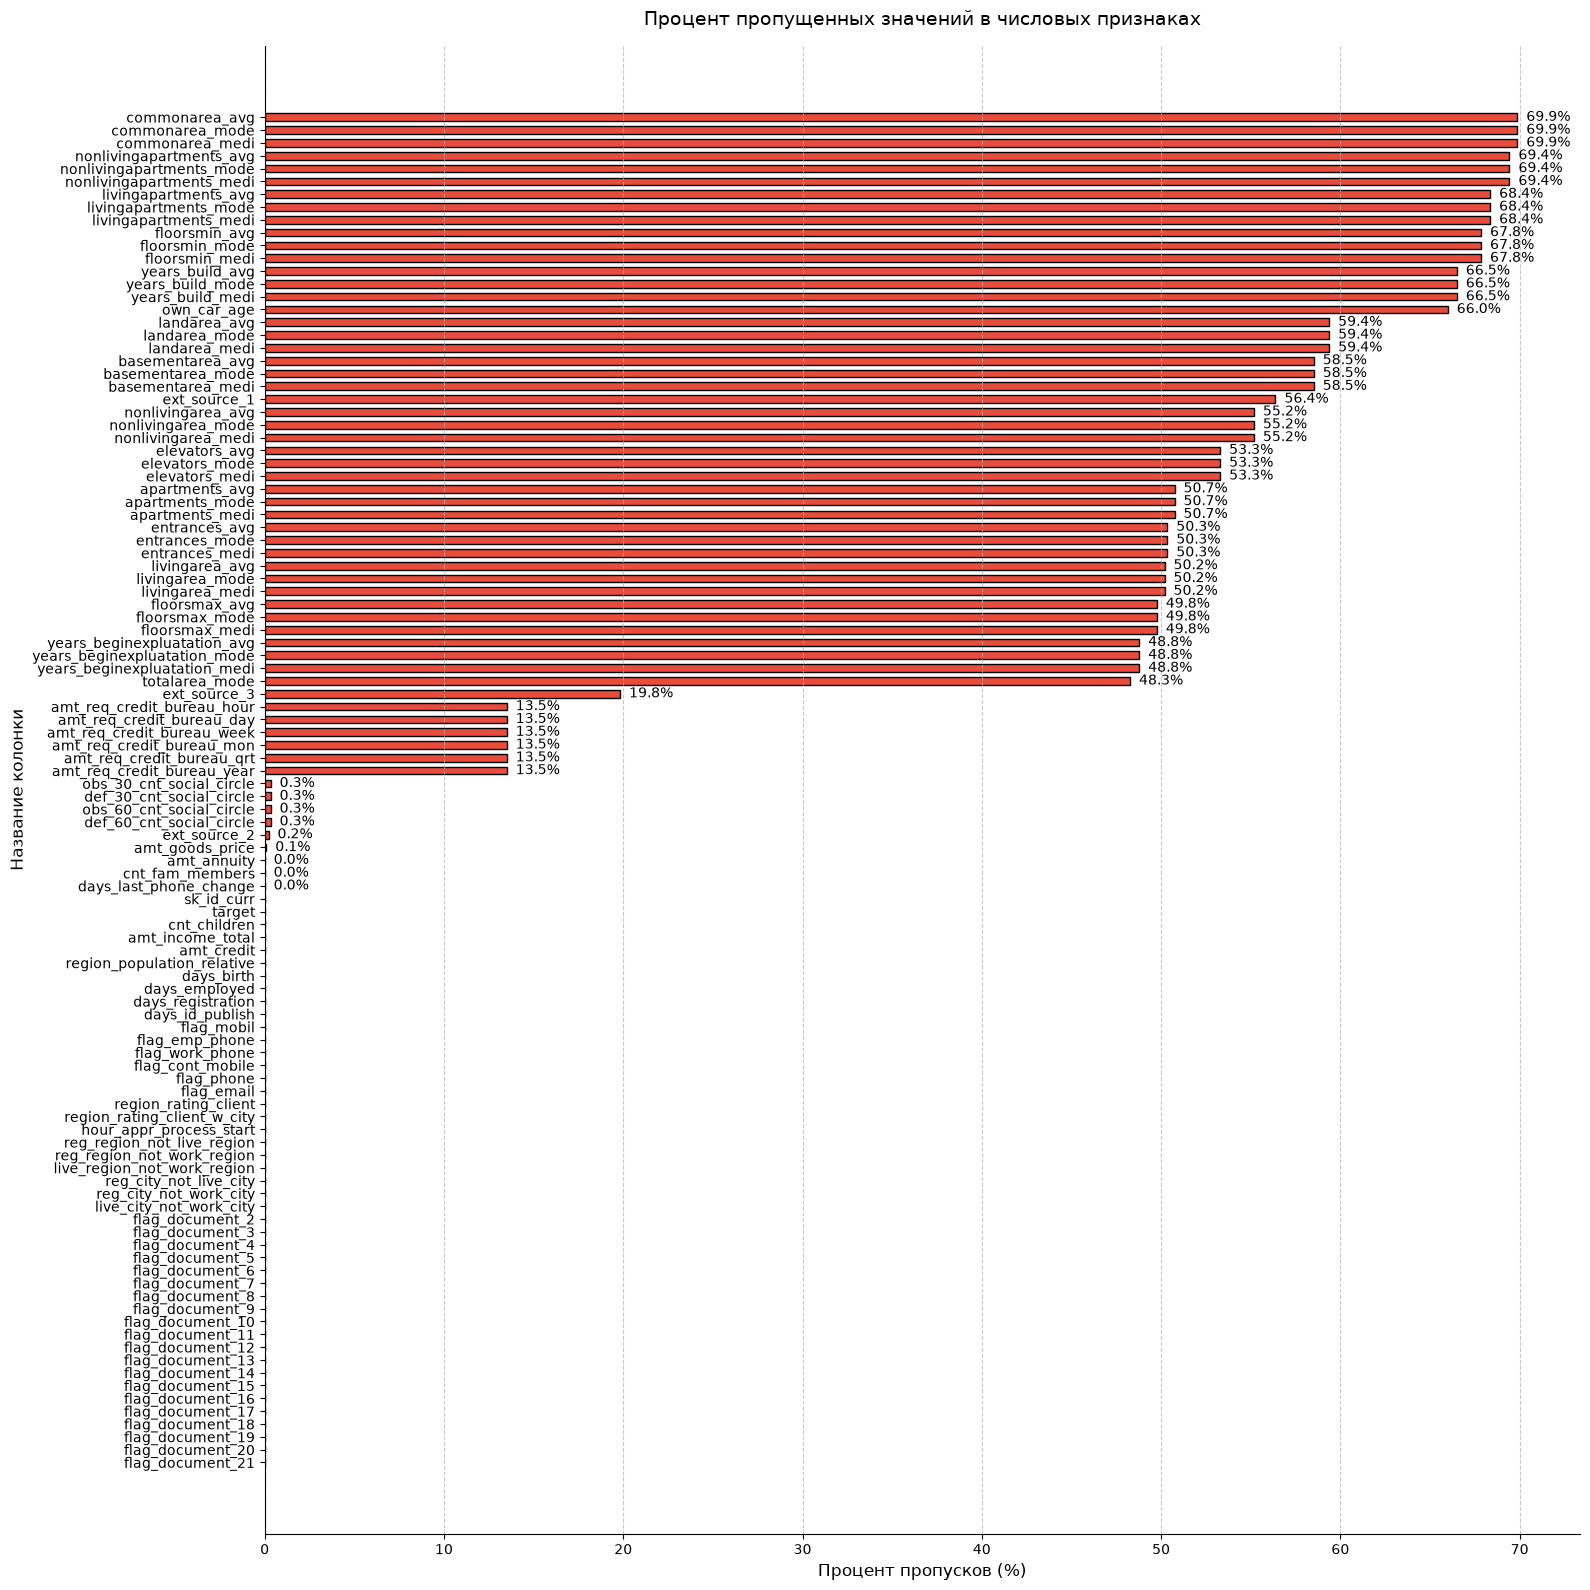

In [13]:
import matplotlib.pyplot as plt


columns = numeric_nulls["column_name"].to_list()
percentages = numeric_nulls["null_percentage"].to_list()


columns.reverse()
percentages.reverse()


fig, ax = plt.subplots(figsize=(16, 16))


bars = ax.barh(columns, percentages, color="#e74c3c", edgecolor="black", height=0.6)

for bar in bars:
    width = bar.get_width()
    if width > 0:  
        ax.text(
            width + 0.5,             
            bar.get_y() + bar.get_height()/2,  
            f'{width:.1f}%',         
            va='center',             
            ha='left',               
            fontsize=10
        )

ax.set_title("Процент пропущенных значений в числовых признаках", fontsize=14, pad=15)
ax.set_xlabel("Процент пропусков (%)", fontsize=12)
ax.set_ylabel("Название колонки", fontsize=12)




ax.grid(axis='x', linestyle='--', alpha=0.7)


for spine in ['top', 'right']:
    ax.spines[spine].set_visible(False)

plt.tight_layout()
plt.show()


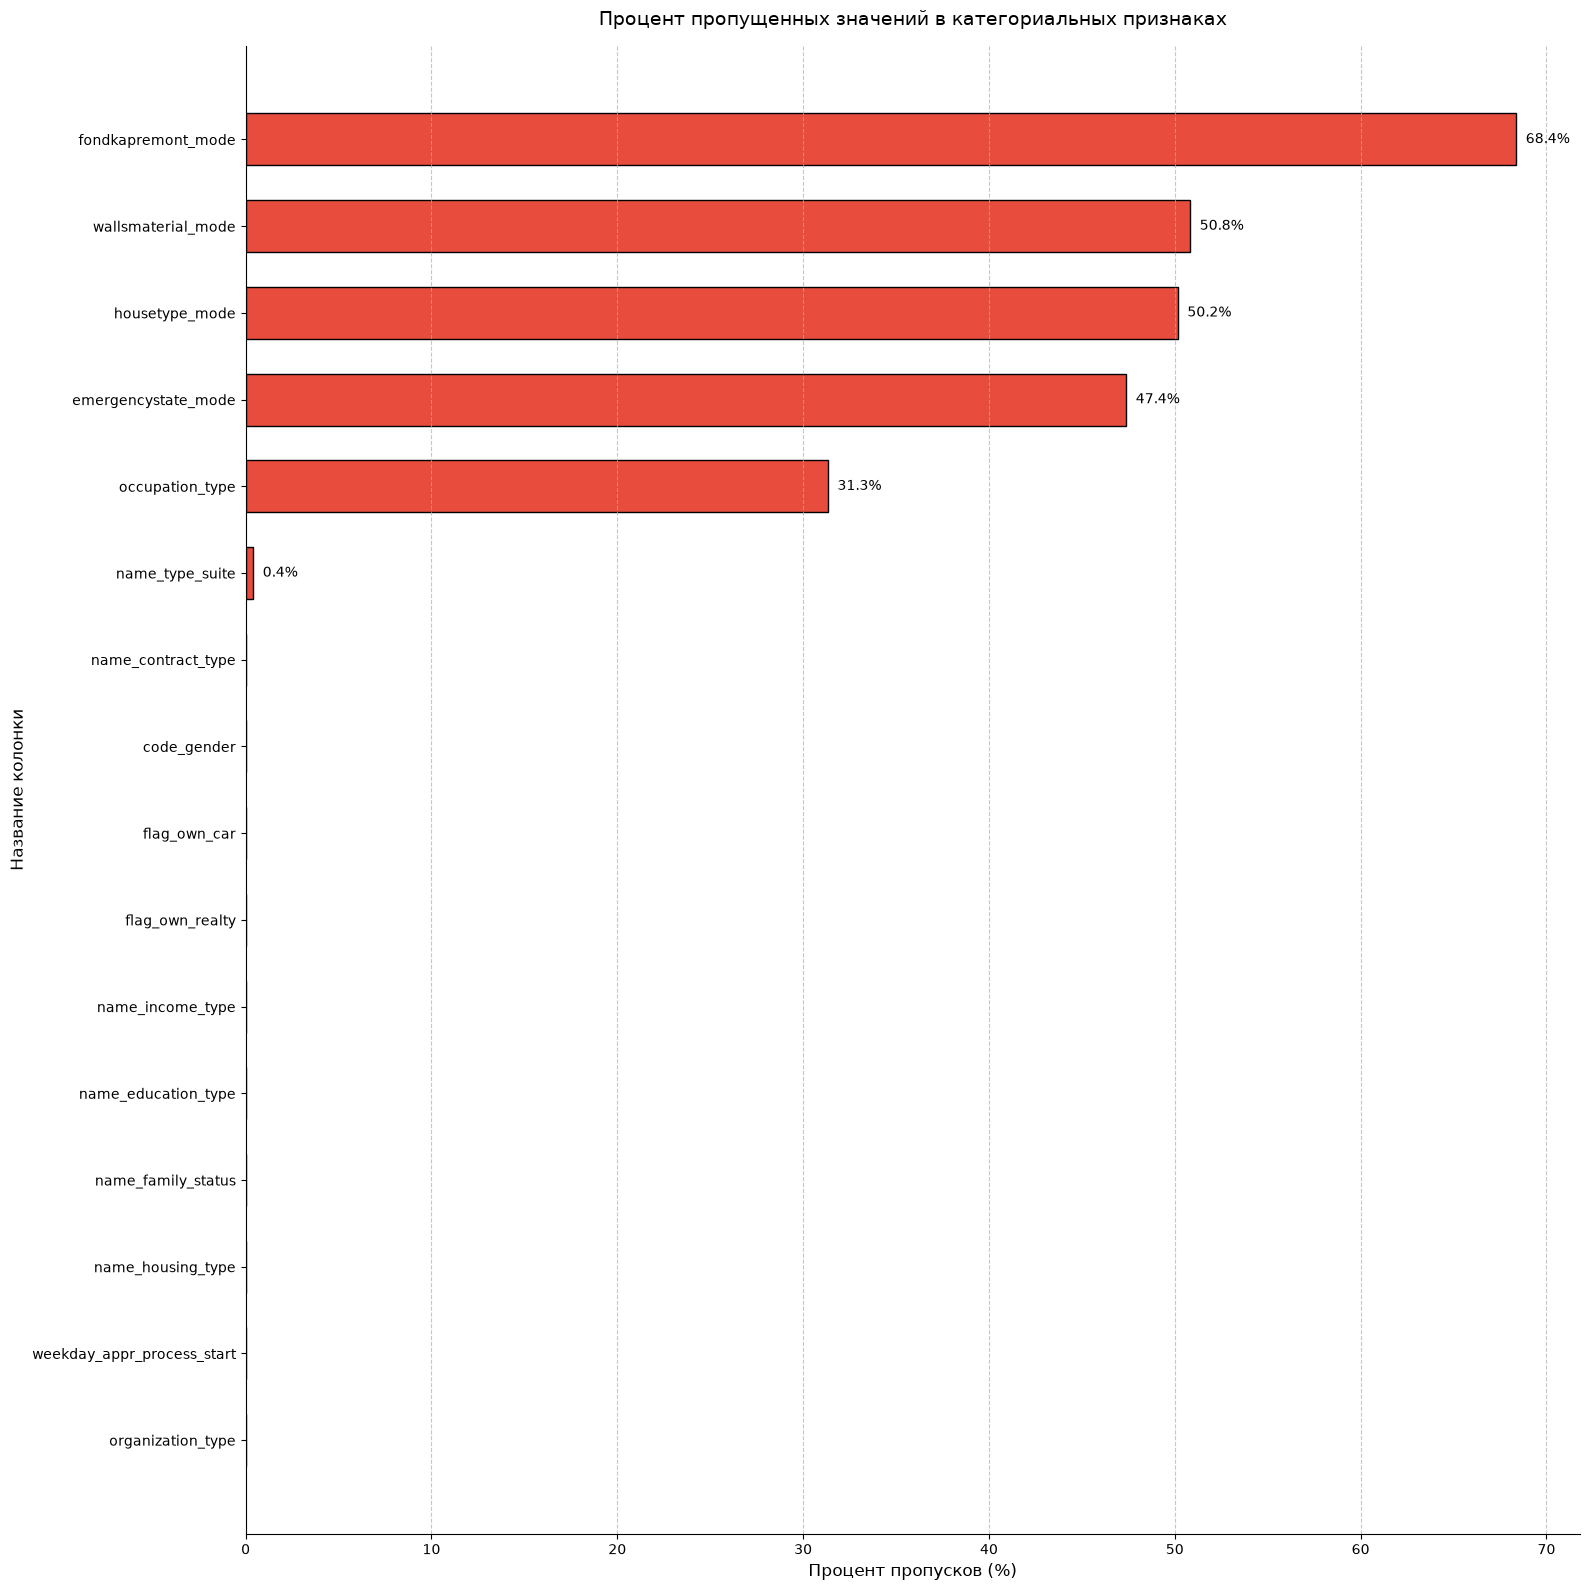

In [14]:
import matplotlib.pyplot as plt


columns = categorical_nulls["column_name"].to_list()
percentages = categorical_nulls["null_percentage"].to_list()


columns.reverse()
percentages.reverse()


fig, ax = plt.subplots(figsize=(16, 16))


bars = ax.barh(columns, percentages, color="#e74c3c", edgecolor="black", height=0.6)


for bar in bars:
    width = bar.get_width()
    if width > 0:  
        ax.text(
            width + 0.5,             
            bar.get_y() + bar.get_height()/2,  
            f'{width:.1f}%',         
            va='center',             
            ha='left',               
            fontsize=10
        )

# 
ax.set_title("Процент пропущенных значений в категориальных признаках", fontsize=14, pad=15)
ax.set_xlabel("Процент пропусков (%)", fontsize=12)
ax.set_ylabel("Название колонки", fontsize=12)


ax.grid(axis='x', linestyle='--', alpha=0.7)


for spine in ['top', 'right']:
    ax.spines[spine].set_visible(False)

plt.tight_layout()
plt.show()


shape: (2, 3)
┌────────┬────────┬────────────┐
│ target ┆ count  ┆ percentage │
│ ---    ┆ ---    ┆ ---        │
│ i64    ┆ u32    ┆ f64        │
╞════════╪════════╪════════════╡
│ 0      ┆ 282686 ┆ 91.927118  │
│ 1      ┆ 24825  ┆ 8.072882   │
└────────┴────────┴────────────┘


C:\Users\kozin\AppData\Local\Temp\ipykernel_12024\16538428.py:3: DeprecationWarning: `pl.count()` is deprecated. Please use `pl.len()` instead.
(Deprecated in version 0.20.5)
  .agg(pl.count().alias("count"))


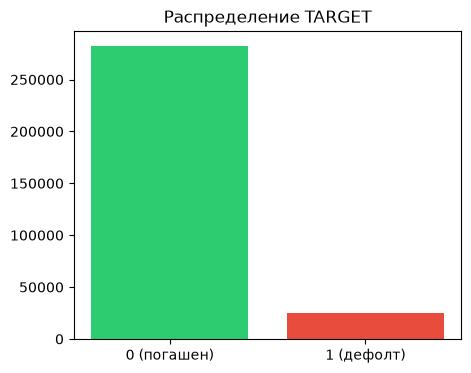

In [15]:
target_balance = (
    train_df.group_by("target")
    .agg(pl.count().alias("count"))
    .with_columns((pl.col("count") / train_df.height * 100).alias("percentage"))
    .sort("target")
)
print(target_balance)

fig, ax = plt.subplots(figsize=(5, 4))
ax.bar(["0 (погашен)", "1 (дефолт)"], target_balance["count"].to_list(), color=["#2ecc71", "#e74c3c"])
ax.set_title("Распределение TARGET")
plt.show()

In [16]:
print(train_df["days_employed"].describe())
# скорее всего увидишь max = 365243 — это заглушка "не работает"

anomaly_flag = train_df.filter(pl.col("days_employed") == 365243).height
print(f"Строк с аномалией: {anomaly_flag} ({anomaly_flag/train_df.height*100:.1f}%)")

# посмотри, коррелирует ли сама аномалия с таргетом
train_df = train_df.with_columns(
    (pl.col("days_employed") == 365243).alias("days_employed_anomaly")
)
print(train_df.group_by("days_employed_anomaly").agg(pl.col("target").mean()))

shape: (9, 2)
┌────────────┬───────────────┐
│ statistic  ┆ value         │
│ ---        ┆ ---           │
│ str        ┆ f64           │
╞════════════╪═══════════════╡
│ count      ┆ 307511.0      │
│ null_count ┆ 0.0           │
│ mean       ┆ 63815.045904  │
│ std        ┆ 141275.766519 │
│ min        ┆ -17912.0      │
│ 25%        ┆ -2760.0       │
│ 50%        ┆ -1213.0       │
│ 75%        ┆ -289.0        │
│ max        ┆ 365243.0      │
└────────────┴───────────────┘
Строк с аномалией: 55374 (18.0%)
shape: (2, 2)
┌───────────────────────┬──────────┐
│ days_employed_anomaly ┆ target   │
│ ---                   ┆ ---      │
│ bool                  ┆ f64      │
╞═══════════════════════╪══════════╡
│ true                  ┆ 0.053996 │
│ false                 ┆ 0.0866   │
└───────────────────────┴──────────┘


In [17]:
candidates = ["ext_source_1", "ext_source_2", "ext_source_3"] + [
    c for c in numeric_nulls["column_name"].to_list()[:20] 
]
candidates = list(dict.fromkeys(candidates))  

corr_with_target = (
    train_df.select([pl.corr(c, "target").alias(c) for c in candidates if c != "target"])
    .transpose(include_header=True, header_name="feature", column_names=["corr_with_target"])
    .with_columns(pl.col("corr_with_target").abs().alias("abs_corr"))
    .sort("abs_corr", descending=True)
)
print(corr_with_target)

shape: (23, 3)
┌──────────────────────────┬──────────────────┬──────────┐
│ feature                  ┆ corr_with_target ┆ abs_corr │
│ ---                      ┆ ---              ┆ ---      │
│ str                      ┆ f64              ┆ f64      │
╞══════════════════════════╪══════════════════╪══════════╡
│ ext_source_3             ┆ -0.178919        ┆ 0.178919 │
│ ext_source_2             ┆ -0.160472        ┆ 0.160472 │
│ ext_source_1             ┆ -0.155317        ┆ 0.155317 │
│ own_car_age              ┆ 0.037612         ┆ 0.037612 │
│ floorsmin_avg            ┆ -0.033614        ┆ 0.033614 │
│ …                        ┆ …                ┆ …        │
│ landarea_avg             ┆ -0.010885        ┆ 0.010885 │
│ landarea_mode            ┆ -0.010174        ┆ 0.010174 │
│ nonlivingapartments_avg  ┆ -0.003176        ┆ 0.003176 │
│ nonlivingapartments_medi ┆ -0.002757        ┆ 0.002757 │
│ nonlivingapartments_mode ┆ -0.001557        ┆ 0.001557 │
└──────────────────────────┴─────────────

In [18]:
bureau_df = pl.read_csv("C:/CreditScoringMLE/ml_service/app/data/bureau.csv")
prev_app_df = pl.read_csv("C:/CreditScoringMLE/ml_service/app/data/previous_application.csv")

for name, df in [("bureau", bureau_df), ("previous_application", prev_app_df)]:
    per_client = df.group_by("SK_ID_CURR").agg(pl.count().alias("n"))
    print(f"{name}: среднее записей на клиента = {per_client['n'].mean():.2f}, макс = {per_client['n'].max()}")

bureau: среднее записей на клиента = 5.61, макс = 116
previous_application: среднее записей на клиента = 4.93, макс = 77


C:\Users\kozin\AppData\Local\Temp\ipykernel_12024\2921063732.py:5: DeprecationWarning: `pl.count()` is deprecated. Please use `pl.len()` instead.
(Deprecated in version 0.20.5)
  per_client = df.group_by("SK_ID_CURR").agg(pl.count().alias("n"))


In [19]:
train_df.write_parquet("C:/CreditScoringMLE/ml_service/app/data/train_eda.parquet")
test_df.write_parquet("C:/CreditScoringMLE/ml_service/app/data/test_eda.parquet")